In [1]:
words = open('Indian_Names.txt', 'r').read().lower().splitlines()

In [2]:
words[:10]

['aaban',
 'aabharan',
 'aabhas',
 'aabhat',
 'aabheer',
 'abheer',
 'aabher',
 'aabi',
 'aabilesh',
 'aabir']

In [3]:
len(words)

53982

In [4]:
min(len(w) for w in words)

2

In [5]:
max(len(w) for w in words)

24

## Biagram
* A Bigram Model guesses the next word based only on the single word that comes right before it.

* Context: They help computers capture basic word combinations and local context better than looking at single words alone.

* Limitations: Modern AI tools use advanced transformer architecture instead of simple bigrams, but bigrams remain a helpful baseline for learning how Statistical Language Modeling works.

In [6]:
b = {}
for w in words:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram , 0) + 1

In [7]:
b

{('<S>', 'a'): 6476,
 ('a', 'a'): 4483,
 ('a', 'b'): 1431,
 ('b', 'a'): 1747,
 ('a', 'n'): 25646,
 ('n', '<E>'): 13513,
 ('b', 'h'): 1283,
 ('h', 'a'): 18167,
 ('a', 'r'): 10752,
 ('r', 'a'): 10543,
 ('a', 's'): 5382,
 ('s', '<E>'): 458,
 ('a', 't'): 5185,
 ('t', '<E>'): 1088,
 ('h', 'e'): 2381,
 ('e', 'e'): 4232,
 ('e', 'r'): 1126,
 ('r', '<E>'): 1584,
 ('b', 'i'): 916,
 ('i', '<E>'): 8863,
 ('i', 'l'): 2118,
 ('l', 'e'): 620,
 ('e', 's'): 3516,
 ('s', 'h'): 14246,
 ('h', '<E>'): 4551,
 ('i', 'r'): 2754,
 ('i', 's'): 4328,
 ('a', 'y'): 2714,
 ('y', 'a'): 7506,
 ('a', 'c'): 303,
 ('c', 'h'): 1718,
 ('r', 'y'): 311,
 ('a', '<E>'): 16312,
 ('h', 'm'): 465,
 ('m', 'a'): 5546,
 ('h', 'u'): 2497,
 ('u', 't'): 1225,
 ('t', 'h'): 15185,
 ('a', 'd'): 2117,
 ('d', 'a'): 1791,
 ('a', 'l'): 3842,
 ('l', 'a'): 4496,
 ('a', 'g'): 1544,
 ('g', 'a'): 2754,
 ('s', 'a'): 4203,
 ('a', 'z'): 232,
 ('z', 'h'): 384,
 ('a', 'm'): 3845,
 ('m', 'y'): 239,
 ('n', 'y'): 762,
 ('r', 'k'): 136,
 ('k', 'o'): 449,


In [8]:
sorted(b.items(), key = lambda kv: -kv[1])

[(('a', 'n'), 25646),
 (('h', 'a'), 18167),
 (('a', '<E>'), 16312),
 (('t', 'h'), 15185),
 (('s', 'h'), 14246),
 (('n', '<E>'), 13513),
 (('a', 'r'), 10752),
 (('r', 'a'), 10543),
 (('i', '<E>'), 8863),
 (('h', 'i'), 8170),
 (('n', 'a'), 7889),
 (('y', 'a'), 7506),
 (('n', 'i'), 6941),
 (('k', 'a'), 6619),
 (('<S>', 'a'), 6476),
 (('v', 'a'), 6045),
 (('m', 'a'), 5546),
 (('a', 's'), 5382),
 (('a', 't'), 5185),
 (('i', 'n'), 5154),
 (('<S>', 's'), 5140),
 (('r', 'i'), 4935),
 (('i', 't'), 4881),
 (('h', '<E>'), 4551),
 (('l', 'a'), 4496),
 (('a', 'a'), 4483),
 (('v', 'i'), 4469),
 (('i', 's'), 4328),
 (('<S>', 'k'), 4233),
 (('e', 'e'), 4232),
 (('s', 'a'), 4203),
 (('<S>', 'v'), 4106),
 (('<S>', 'm'), 3849),
 (('a', 'm'), 3845),
 (('a', 'l'), 3842),
 (('a', 'v'), 3635),
 (('<S>', 'n'), 3551),
 (('e', 's'), 3516),
 (('<S>', 'r'), 3353),
 (('j', 'a'), 3343),
 (('i', 'k'), 3324),
 (('<S>', 'p'), 3289),
 (('d', 'h'), 3034),
 (('n', 't'), 3025),
 (('e', 'n'), 3011),
 (('<S>', 'd'), 2965),


In [9]:
import torch

In [10]:
a = torch.zeros((3,5), dtype = torch.int32)
a

tensor([[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]], dtype=torch.int32)

In [11]:
a[1,3] = 1
a[0,0] = 67
a

tensor([[67,  0,  0,  0,  0],
        [ 0,  0,  0,  1,  0],
        [ 0,  0,  0,  0,  0]], dtype=torch.int32)

In [12]:
N = torch.zeros((27, 27), dtype=torch.int32)

In [13]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [14]:
for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    N[ix1, ix2] += 1
    

In [15]:
itos = {s:i for i,s in stoi.items()}
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [16]:
type(N[3, 3].item())

int

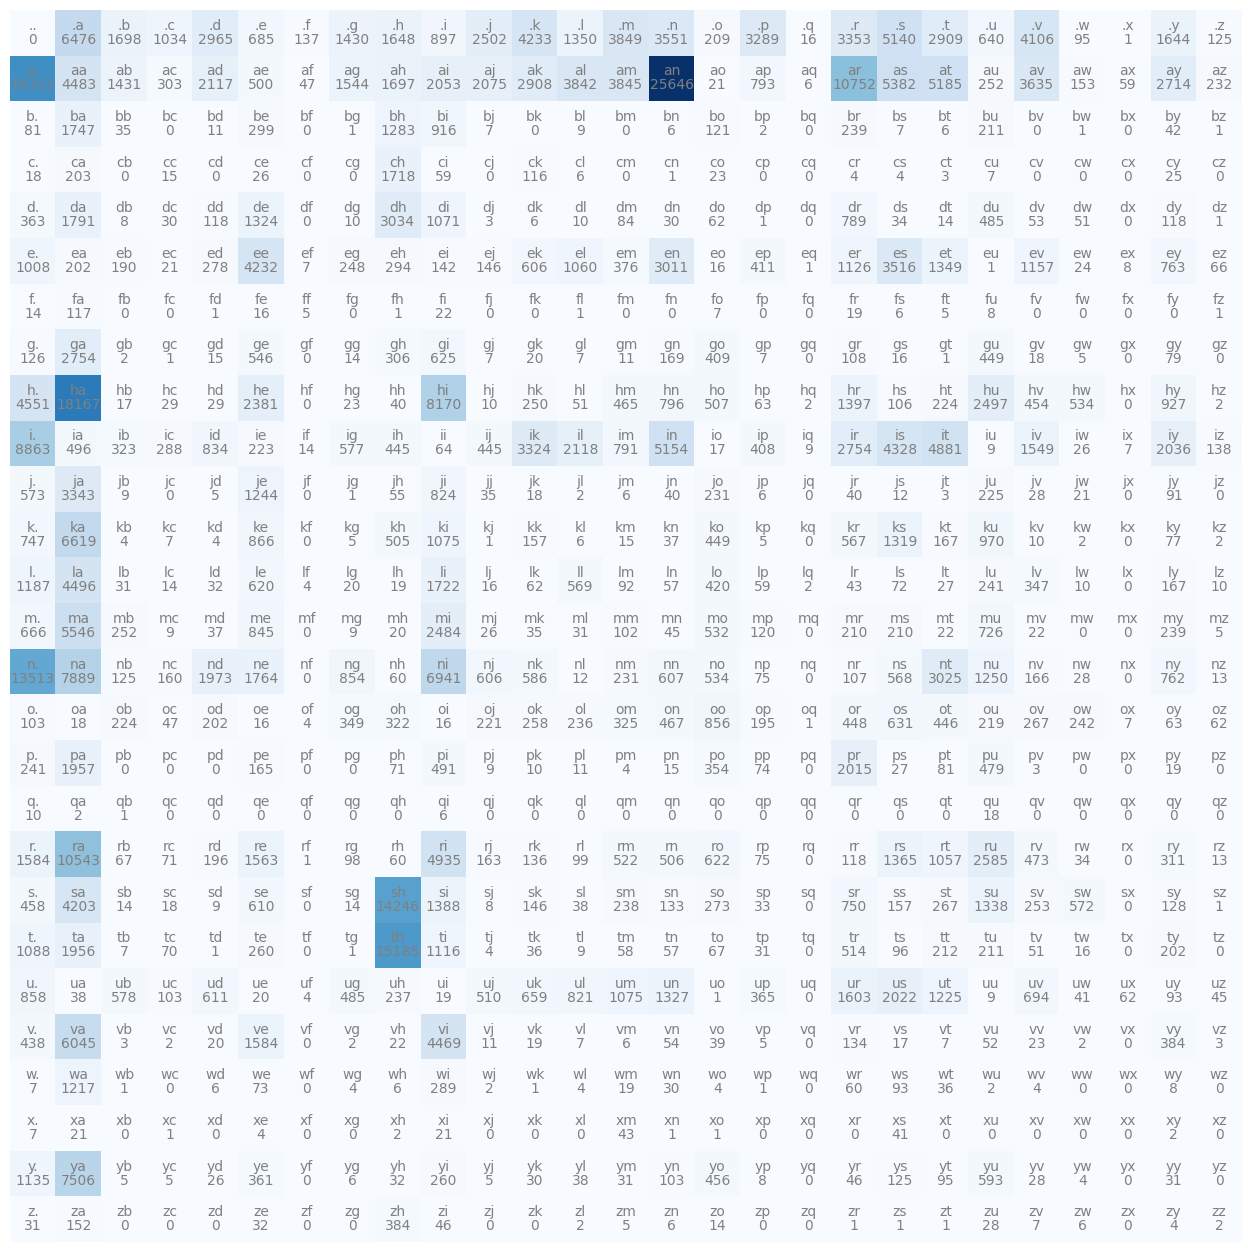

In [17]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');

In [18]:
N[0]

tensor([   0, 6476, 1698, 1034, 2965,  685,  137, 1430, 1648,  897, 2502, 4233,
        1350, 3849, 3551,  209, 3289,   16, 3353, 5140, 2909,  640, 4106,   95,
           1, 1644,  125], dtype=torch.int32)

In [19]:
p = N[0].float()
p = p / p.sum()
p

tensor([0.0000e+00, 1.1997e-01, 3.1455e-02, 1.9155e-02, 5.4926e-02, 1.2689e-02,
        2.5379e-03, 2.6490e-02, 3.0529e-02, 1.6617e-02, 4.6349e-02, 7.8415e-02,
        2.5008e-02, 7.1302e-02, 6.5781e-02, 3.8717e-03, 6.0928e-02, 2.9640e-04,
        6.2113e-02, 9.5217e-02, 5.3888e-02, 1.1856e-02, 7.6062e-02, 1.7598e-03,
        1.8525e-05, 3.0455e-02, 2.3156e-03])

In [20]:
g = torch.Generator().manual_seed(2147483647)
ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
itos[ix]

'd'

In [21]:
p.shape

torch.Size([27])

In [22]:
P = (N+1).float()  #model smoothing
# added +1 to N to smooth out the generation as if we do N and if a prediction is 0 it will give infinity as loss
# to fix we add 1 as least

In [23]:
P.sum()

tensor(488803.)

In [24]:
P.sum(1, keepdims=True)

tensor([[5.4009e+04],
        [9.8014e+04],
        [5.0520e+03],
        [2.2550e+03],
        [9.5170e+03],
        [2.0286e+04],
        [2.5000e+02],
        [5.7220e+03],
        [4.1719e+04],
        [4.0148e+04],
        [6.8390e+03],
        [1.3643e+04],
        [1.0366e+04],
        [1.2220e+04],
        [4.1876e+04],
        [6.2720e+03],
        [6.0530e+03],
        [6.4000e+01],
        [2.7224e+04],
        [2.5322e+04],
        [2.1275e+04],
        [1.3532e+04],
        [1.3375e+04],
        [1.8940e+03],
        [1.7100e+02],
        [1.0956e+04],
        [7.4900e+02]])

In [25]:
P.sum(1, keepdims=True).shape

torch.Size([27, 1])

In [26]:
P /= P.sum(1, keepdims=True)

In [27]:
P.sum()

tensor(27.0000)

In [28]:
P.shape

torch.Size([27, 27])

In [29]:
P.sum(0)

tensor([1.9715, 7.3870, 0.2283, 0.1052, 0.3086, 1.4853, 0.0546, 0.2246, 3.4372,
        2.6852, 0.2250, 0.4574, 0.3835, 0.6595, 0.9640, 0.6536, 0.2281, 0.0305,
        1.2851, 1.2511, 0.7071, 1.1770, 0.4417, 0.1335, 0.0364, 0.4154, 0.0637])

In [30]:
P.sum(0).shape

torch.Size([27])

In [31]:
P.sum(1).shape

torch.Size([27])

In [32]:
# 27, 27
#  1, 27

In [33]:
g = torch.Generator().manual_seed(2147483647)

for i in range(5):
  
  out = []
  ix = 0
  while True:
    p = P[ix]
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[ix])
    if ix == 0:
      break
  print(''.join(out))

deeba.
pogakurari.
jitaharvinimithain.
lanak.
kan.


In [34]:
# evaluating the model

In [35]:
# GOAL: maximize likelihood of the data w.r.t. model parameters (statistical modeling)
# equivalent to maximizing the log likelihood (because log is monotonic)
# equivalent to minimizing the negative log likelihood
# equivalent to minimizing the average negative log likelihood

# log(a*b*c) = log(a) + log(b) + log(c)

In [36]:
log_likelihood = 0.0
n = 0
# likelihood = which is the product of all probalilities assigned by the model

for w in words[:3]:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    prob = P[ix1, ix2]
    logprob = torch.log(prob)
    log_likelihood += logprob    
    n += 1
    print(f'{ch1}{ch2}: {prob:.4f} {logprob:.4f}')
print(f'log_likelihood = {log_likelihood}')
nll = -log_likelihood
print(f'{nll=}')  #nll = negative log likelihood
print(f'{nll/n}') #nll/n = normlaize it by count 
# lower nll is  = best it is
# higer nll is = worse it is

.a: 0.1199 -2.1209
aa: 0.0457 -3.0846
ab: 0.0146 -4.2260
ba: 0.3460 -1.0613
an: 0.2617 -1.3407
n.: 0.3227 -1.1310
.a: 0.1199 -2.1209
aa: 0.0457 -3.0846
ab: 0.0146 -4.2260
bh: 0.2542 -1.3698
ha: 0.4355 -0.8313
ar: 0.1097 -2.2099
ra: 0.3873 -0.9485
an: 0.2617 -1.3407
n.: 0.3227 -1.1310
.a: 0.1199 -2.1209
aa: 0.0457 -3.0846
ab: 0.0146 -4.2260
bh: 0.2542 -1.3698
ha: 0.4355 -0.8313
as: 0.0549 -2.9019
s.: 0.0181 -4.0104
log_likelihood = -48.77214050292969
nll=tensor(48.7721)
2.2169153690338135


In [37]:
# nll is inversally prop to model quatlity

In [53]:
#create the training set of all the biagrams
xs, ys = [], []

for w in words[:1]:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    print(ch1, ch2)
    xs.append(ix1)
    ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)

. a
a a
a b
b a
a n
n .


In [54]:
xs

tensor([ 0,  1,  1,  2,  1, 14])

In [55]:
ys

tensor([ 1,  1,  2,  1, 14,  0])

In [65]:
import torch.nn.functional as F
xenc = F.one_hot(xs, num_classes = 27).float()
xenc

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [66]:
xenc.shape

torch.Size([6, 27])

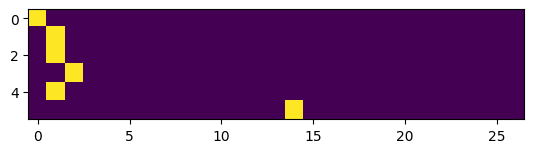

In [67]:
plt.imshow(xenc)

In [68]:
xenc.dtype

torch.float32

In [78]:
W = torch.randn((27, 27))
xenc @ W  #@ is matrix multiplicantion in pytorch

tensor([[ 0.6929, -0.9206, -1.2775,  0.2878,  0.9952,  0.3910,  0.1081, -0.5208,
         -0.9309,  0.8223, -0.3351, -1.1917,  2.2591,  0.3605, -0.8550, -0.8168,
         -0.2546, -2.0290,  1.0877, -1.3027, -0.4758,  1.7355, -1.1759, -1.6792,
          0.7122, -1.4959, -0.3840],
        [ 1.3955,  0.5974, -1.5359, -2.1259, -0.6539,  1.0273,  0.5299,  0.6603,
          0.1433,  0.3906,  1.1148,  0.6800, -0.6173,  1.6937,  2.5793,  0.1264,
          1.3499, -0.5677, -0.7092, -0.6302, -0.0932,  1.8613,  0.6961, -0.7238,
          0.7713,  1.5201,  0.1253],
        [ 1.3955,  0.5974, -1.5359, -2.1259, -0.6539,  1.0273,  0.5299,  0.6603,
          0.1433,  0.3906,  1.1148,  0.6800, -0.6173,  1.6937,  2.5793,  0.1264,
          1.3499, -0.5677, -0.7092, -0.6302, -0.0932,  1.8613,  0.6961, -0.7238,
          0.7713,  1.5201,  0.1253],
        [-0.4079,  0.6587, -2.0424, -2.4218, -0.9454,  0.1669, -0.2525,  0.7837,
         -0.9419, -0.7523, -0.8053, -0.1015,  1.1745, -0.0321, -0.2202, -0.5247

In [79]:
(xenc @ W).shape

torch.Size([6, 27])

In [81]:
(xenc @ W)[3,13]

tensor(-0.0321)

In [80]:
# (6,27) @ (27,1) == (6,1)

In [109]:
logits = xenc @ W # log_counts
counts = logits.exp() # equivalent N array that we used previously
#element wise exponietiing the logits
probs = counts / counts.sum(1, keepdims=True)
probs

tensor([[0.0508, 0.0101, 0.0071, 0.0339, 0.0688, 0.0376, 0.0283, 0.0151, 0.0100,
         0.0578, 0.0182, 0.0077, 0.2434, 0.0365, 0.0108, 0.0112, 0.0197, 0.0033,
         0.0754, 0.0069, 0.0158, 0.1442, 0.0078, 0.0047, 0.0518, 0.0057, 0.0173],
        [0.0628, 0.0283, 0.0034, 0.0019, 0.0081, 0.0435, 0.0264, 0.0301, 0.0180,
         0.0230, 0.0475, 0.0307, 0.0084, 0.0847, 0.2053, 0.0177, 0.0600, 0.0088,
         0.0077, 0.0083, 0.0142, 0.1001, 0.0312, 0.0075, 0.0337, 0.0712, 0.0176],
        [0.0628, 0.0283, 0.0034, 0.0019, 0.0081, 0.0435, 0.0264, 0.0301, 0.0180,
         0.0230, 0.0475, 0.0307, 0.0084, 0.0847, 0.2053, 0.0177, 0.0600, 0.0088,
         0.0077, 0.0083, 0.0142, 0.1001, 0.0312, 0.0075, 0.0337, 0.0712, 0.0176],
        [0.0272, 0.0790, 0.0053, 0.0036, 0.0159, 0.0483, 0.0318, 0.0895, 0.0159,
         0.0193, 0.0183, 0.0369, 0.1323, 0.0396, 0.0328, 0.0242, 0.0232, 0.0475,
         0.0535, 0.0439, 0.0206, 0.0541, 0.0712, 0.0178, 0.0197, 0.0116, 0.0169],
        [0.0628, 0.0283,

In [110]:
probs.shape

torch.Size([6, 27])

In [111]:
probs[0]

tensor([0.0508, 0.0101, 0.0071, 0.0339, 0.0688, 0.0376, 0.0283, 0.0151, 0.0100,
        0.0578, 0.0182, 0.0077, 0.2434, 0.0365, 0.0108, 0.0112, 0.0197, 0.0033,
        0.0754, 0.0069, 0.0158, 0.1442, 0.0078, 0.0047, 0.0518, 0.0057, 0.0173])

In [112]:
probs[0].shape

torch.Size([27])

In [113]:
probs[0].sum()

tensor(1.)

In [114]:
# summary ------------------------

In [115]:
xs

tensor([ 0,  1,  1,  2,  1, 14])

In [116]:
ys

tensor([ 1,  1,  2,  1, 14,  0])

In [117]:
# randomly initialize 27 neurons' weights. each neuron receives 27 inputs
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g)

In [118]:
xenc = F.one_hot(xs, num_classes=27).float() # input to the network: one-hot encoding
logits = xenc @ W # predict log_counts
counts = logits.exp() # counts, equivalent to N
probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
# btw: the last 2 lines here are together called a 'softmax'

In [119]:
probs.shape

torch.Size([6, 27])

In [120]:
nlls = torch.zeros(6)
for i in range(6):
  # i-th bigram:
  x = xs[i].item() # input character index
  y = ys[i].item() # label character index
  print('--------')
  print(f'bigram example {i+1}: {itos[x]}{itos[y]} (indexes {x},{y})')
  print('input to the neural net:', x)
  print('output probabilities from the neural net:', probs[i])
  print('label (actual next character):', y)
  p = probs[i, y]
  print('probability assigned by the net to the the correct character:', p.item())
  logp = torch.log(p)
  print('log likelihood:', logp.item())
  nll = -logp
  print('negative log likelihood:', nll.item())
  nlls[i] = nll

print('=========')
print('average negative log likelihood, i.e. loss =', nlls.mean().item())

--------
bigram example 1: .a (indexes 0,1)
input to the neural net: 0
output probabilities from the neural net: tensor([0.0607, 0.0100, 0.0123, 0.0042, 0.0168, 0.0123, 0.0027, 0.0232, 0.0137,
        0.0313, 0.0079, 0.0278, 0.0091, 0.0082, 0.0500, 0.2378, 0.0603, 0.0025,
        0.0249, 0.0055, 0.0339, 0.0109, 0.0029, 0.0198, 0.0118, 0.1537, 0.1459])
label (actual next character): 1
probability assigned by the net to the the correct character: 0.009982486255466938
log likelihood: -4.6069231033325195
negative log likelihood: 4.6069231033325195
--------
bigram example 2: aa (indexes 1,1)
input to the neural net: 1
output probabilities from the neural net: tensor([0.0150, 0.0086, 0.0396, 0.0100, 0.0606, 0.0308, 0.1084, 0.0131, 0.0125,
        0.0048, 0.1024, 0.0086, 0.0988, 0.0112, 0.0232, 0.0207, 0.0408, 0.0078,
        0.0899, 0.0531, 0.0463, 0.0309, 0.0051, 0.0329, 0.0654, 0.0503, 0.0091])
label (actual next character): 1
probability assigned by the net to the the correct character: 0

In [121]:
# optimization ---------------------

In [169]:
xs

tensor([ 0,  1,  1,  2,  1, 14])

In [170]:
ys

tensor([ 1,  1,  2,  1, 14,  0])

In [171]:
# randomly initialize 27 neurons' weights. each neuron receives 27 inputs
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

In [183]:
#forward pass
xenc = F.one_hot(xs, num_classes=27).float() # input to the network: one-hot encoding
logits = xenc @ W # predict log_counts
counts = logits.exp() # counts, equivalent to N
probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
# btw: the last 2 lines here are together called a 'softmax'
loss = -probs[torch.arange(6), ys].log().mean() # this is the vectorization form of this part


#label (actual next character): 0
#probability assigned by the net to the the correct character: 0.15563885867595673
#log likelihood: -1.8602169752120972
#negative log likelihood: 1.8602169752120972
#=========
#average negative log likelihood, i.e. loss = 3.8419463634490967


In [184]:
probs.shape

torch.Size([6, 27])

In [185]:
print(loss.item())

3.808213233947754


In [186]:
# backward pass
W.grad = None # set to zero the gradient
loss.backward()

In [187]:
W.data += -0.1 * W.grad

In [198]:
# --------- !!! OPTIMIZATION !!! yay, but this time actually --------------

In [199]:
# create the dataset
xs, ys = [], []
for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    xs.append(ix1)
    ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print('number of examples: ', num)

# initialize the 'network'
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

number of examples:  488074


In [201]:
# gradient descent
for k in range(100):
  
  # forward pass
  xenc = F.one_hot(xs, num_classes=27).float() # input to the network: one-hot encoding
  logits = xenc @ W # predict log-counts
  counts = logits.exp() # counts, equivalent to N
  probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
  loss = -probs[torch.arange(num), ys].log().mean() + 0.01*(W**2).mean()
  print(loss.item())
  
  # backward pass
  W.grad = None # set to zero the gradient
  loss.backward()
  
  # update
  W.data += -50 * W.grad

2.225017786026001
2.231031656265259
2.2247114181518555
2.230734348297119
2.224419593811035
2.2304506301879883
2.2241413593292236
2.230179786682129
2.2238759994506836
2.2299211025238037
2.2236225605010986
2.2296743392944336
2.2233800888061523
2.229437828063965
2.2231478691101074
2.2292120456695557
2.2229256629943848
2.2289955615997314
2.2227137088775635
2.228788137435913
2.2225098609924316
2.2285895347595215
2.2223145961761475
2.2283992767333984
2.2221269607543945
2.2282161712646484
2.2219467163085938
2.2280402183532715
2.221774101257324
2.2278714179992676
2.2216079235076904
2.2277088165283203
2.2214479446411133
2.227552652359009
2.221294641494751
2.227402448654175
2.2211461067199707
2.227257490158081
2.221003770828247
2.2271180152893066
2.2208659648895264
2.2269837856292725
2.220733880996704
2.226854085922241
2.2206058502197266
2.226729154586792
2.220482349395752
2.2266082763671875
2.2203633785247803
2.226491928100586
2.2202484607696533
2.226378917694092
2.220136880874634
2.22627019882

In [204]:
# finally, sample from the 'neural net' model
g = torch.Generator().manual_seed(2147483647)

for i in range(5):
  
  out = []
  ix = 0
  while True:
    
    # ----------
    # BEFORE:
    #p = P[ix]
    # ----------
    # NOW:
    xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
    logits = xenc @ W # predict log-counts
    counts = logits.exp() # counts, equivalent to N
    p = counts / counts.sum(1, keepdims=True) # probabilities for next character
    # ----------
    
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[ix])
    if ix == 0:
      break
  print(''.join(out))

deeba.
poganurari.
jitaharvinimithanthakavi.
kan.
a.
